Notebook explaining step by step how we build the `compute_likelihood_map` function.

In [1]:
from retinotopy import *
args = Params()

----------------------------------------------------------------------------------
On date 2024-05-14, Running learning on host Ahsoka with device cpu, pytoch==2.2.2
----------------------------------------------------------------------------------
Welcome on macOS-14.5-x86_64-i386-64bit


# Likelihood map on a test image

In [2]:
from torchvision.io import read_image

true_label = 'jaguar'
image_url = './imgs/jaguar_5.jpg'
image_url = './imgs/jaguar.jpg'

true_label = 'tree_frog'
image_url = './imgs/frog.jpg'

full_image = read_image(image_url)/255
full_image_np = torch.movedim(full_image, (1, 2, 0), (0, 1, 2)).numpy()
print(f"{type(full_image) = }, {full_image.dtype = }, {full_image.shape = }")

type(full_image) = <class 'torch.Tensor'>, full_image.dtype = torch.float32, full_image.shape = torch.Size([3, 375, 500])


In [3]:
full_image.min(), full_image.max()

(tensor(0.), tensor(1.))

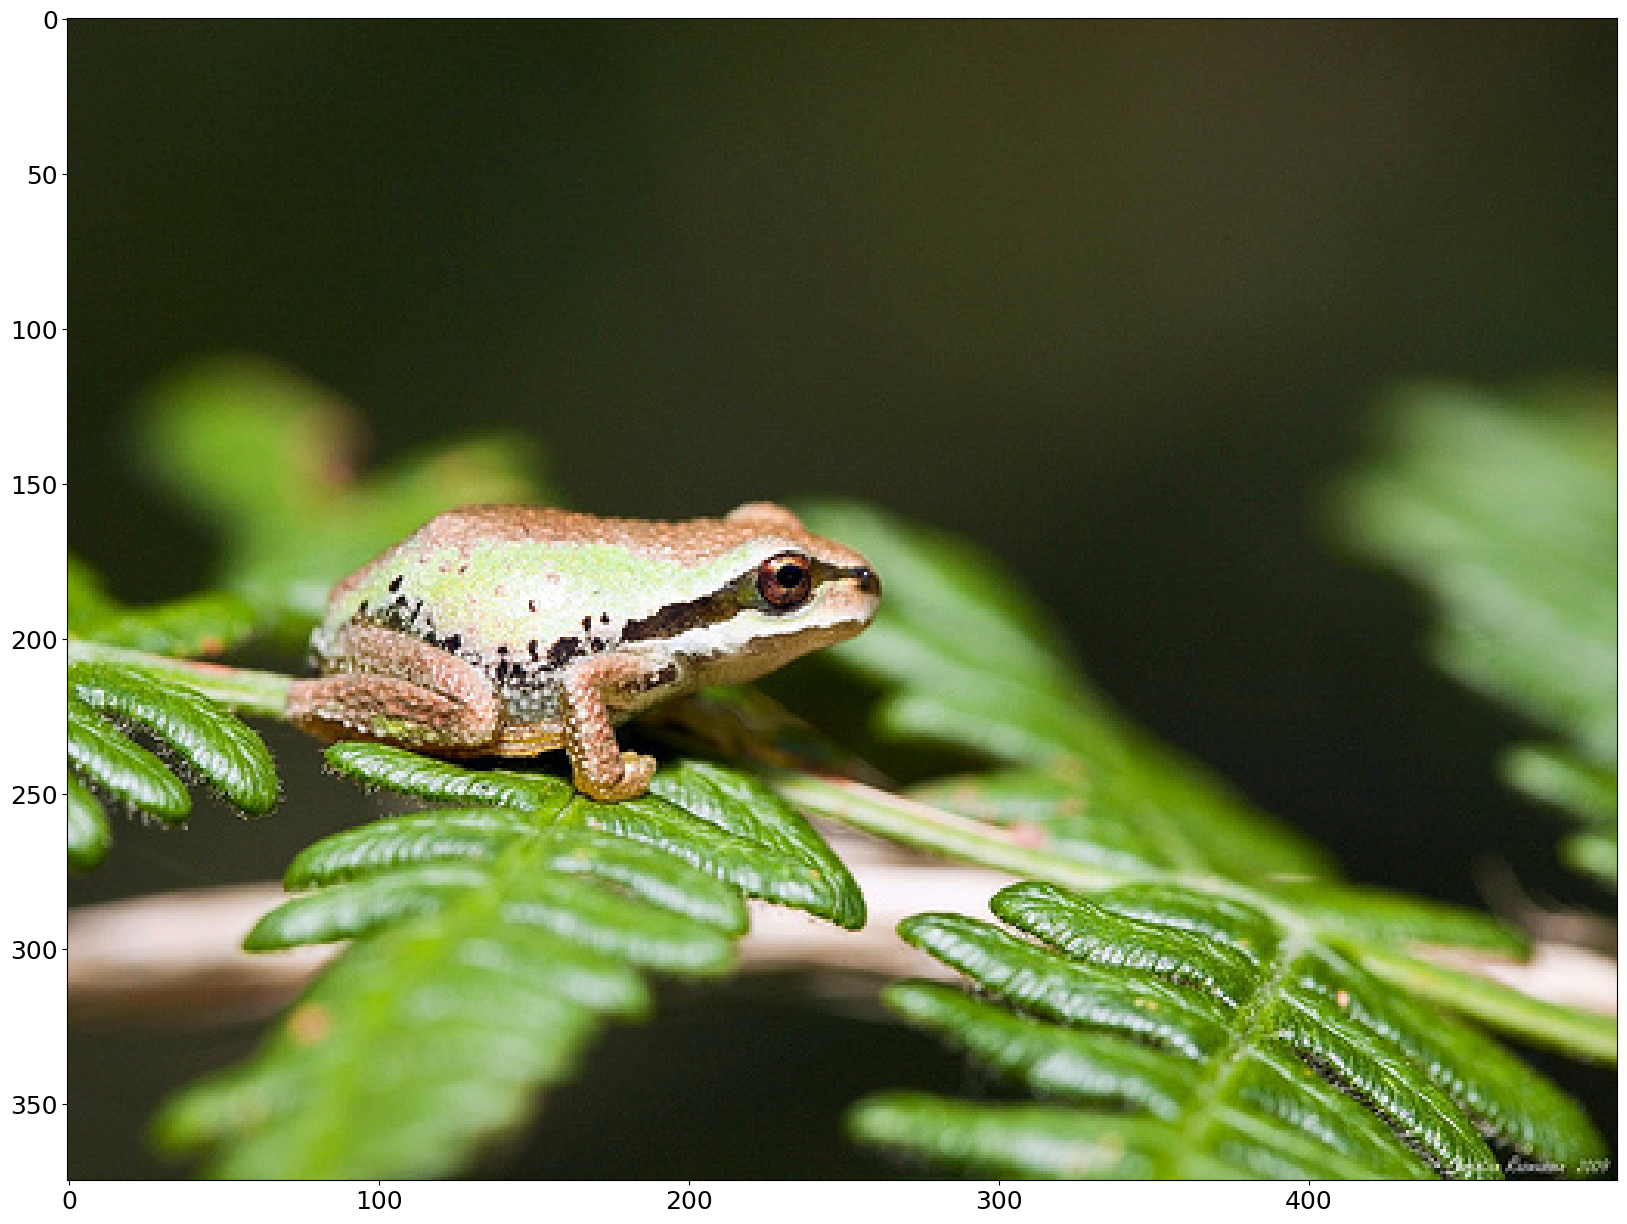

In [4]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.imshow(full_image_np)
# ax.set_xticks([])
# ax.set_yticks([])  
fig.set_facecolor(color='white')

In [5]:
args.do_polar = True
data_transform = get_transforms(args)
out = data_transform(full_image)
print(f"{type(out) = }, {out.dtype = }, {out.shape = }")

type(out) = <class 'torch.Tensor'>, out.dtype = torch.float32, out.shape = torch.Size([3, 224, 224])


## making a grid

### first strategy: valid boxes

In [6]:
resolution = (11, 11) # how many fixation points to use
size_ratio = 0.3 # how much of the image to use relative to radius
N_fixations = np.prod(resolution)

three, H, W = full_image.shape
max_size = np.max((H, W))
min_size = np.min((H, W))
box_size = int(min_size*size_ratio)

if H < W:
    shift = (0, (W-H)/2)
else:
    shift = ((H-W)/2, 0)
min_size, max_size, shift[0], shift[1], box_size

(375, 500, 0, 62.5, 112)

In [7]:
pos_h = np.linspace(shift[0]+box_size/2, min_size+shift[0]-box_size/2, resolution[0], endpoint=True)
pos_w = np.linspace(shift[1]+box_size/2, min_size+shift[1]-box_size/2, resolution[1], endpoint=True)
pos_h, pos_w

(array([ 56. ,  82.3, 108.6, 134.9, 161.2, 187.5, 213.8, 240.1, 266.4,
        292.7, 319. ]),
 array([118.5, 144.8, 171.1, 197.4, 223.7, 250. , 276.3, 302.6, 328.9,
        355.2, 381.5]))

### second strategy: brutal

In [8]:
aspect_ratio = H/W
N_fixations = np.prod(resolution)
resolution = (int(np.sqrt(N_fixations*aspect_ratio)), int(np.sqrt(N_fixations/aspect_ratio)))
N_fixations = np.prod(resolution)
resolution

(9, 12)

In [9]:
pos_h = np.linspace(0, H, resolution[0]+2, endpoint=True)[1:-1]
pos_w = np.linspace(0, W, resolution[1]+2, endpoint=True)[1:-1]
pos_h, pos_w

(array([ 37.5,  75. , 112.5, 150. , 187.5, 225. , 262.5, 300. , 337.5]),
 array([ 38.46153846,  76.92307692, 115.38461538, 153.84615385,
        192.30769231, 230.76923077, 269.23076923, 307.69230769,
        346.15384615, 384.61538462, 423.07692308, 461.53846154]))

In [10]:
pos_H, pos_W = np.meshgrid(pos_h, pos_w)
pos_H.shape, pos_W.shape

((12, 9), (12, 9))

In [11]:
# fixations= np.array(list(p)).T
# fixations.shape

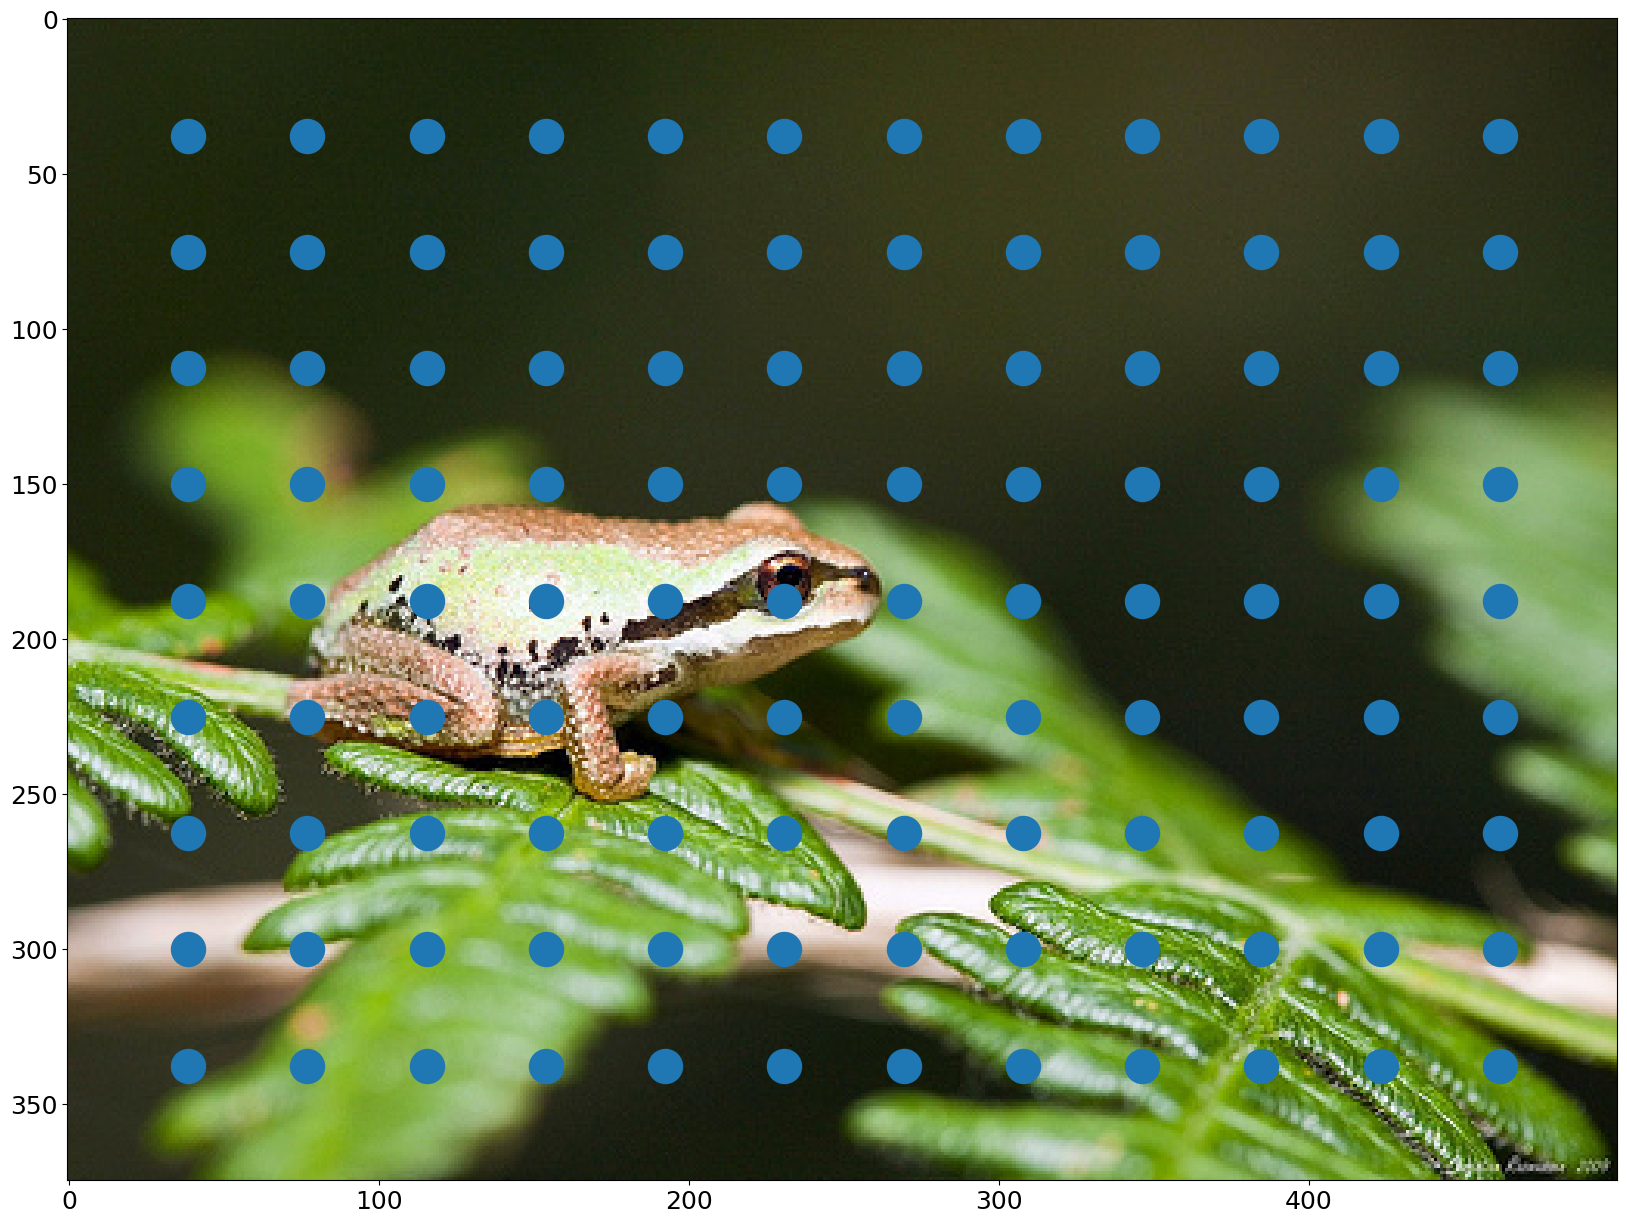

In [12]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.imshow(full_image_np)
# ax.set_xticks([])
ax.scatter(pos_W.ravel(), pos_H.ravel(), s=600)
# ax.set_yticks([])  
fig.set_facecolor(color='white')

In [13]:
args.image_size = box_size
data_transform = get_transforms(args)

In [14]:
# full_image[:, h-box_size//2:h+box_size//2, w-box_size//2:w+box_size//2].shape

In [15]:
# data_transform(full_image[:, h-box_size//2:h+box_size//2, w-box_size//2:w+box_size//2]).shape

do_polar=True
do_polar=False


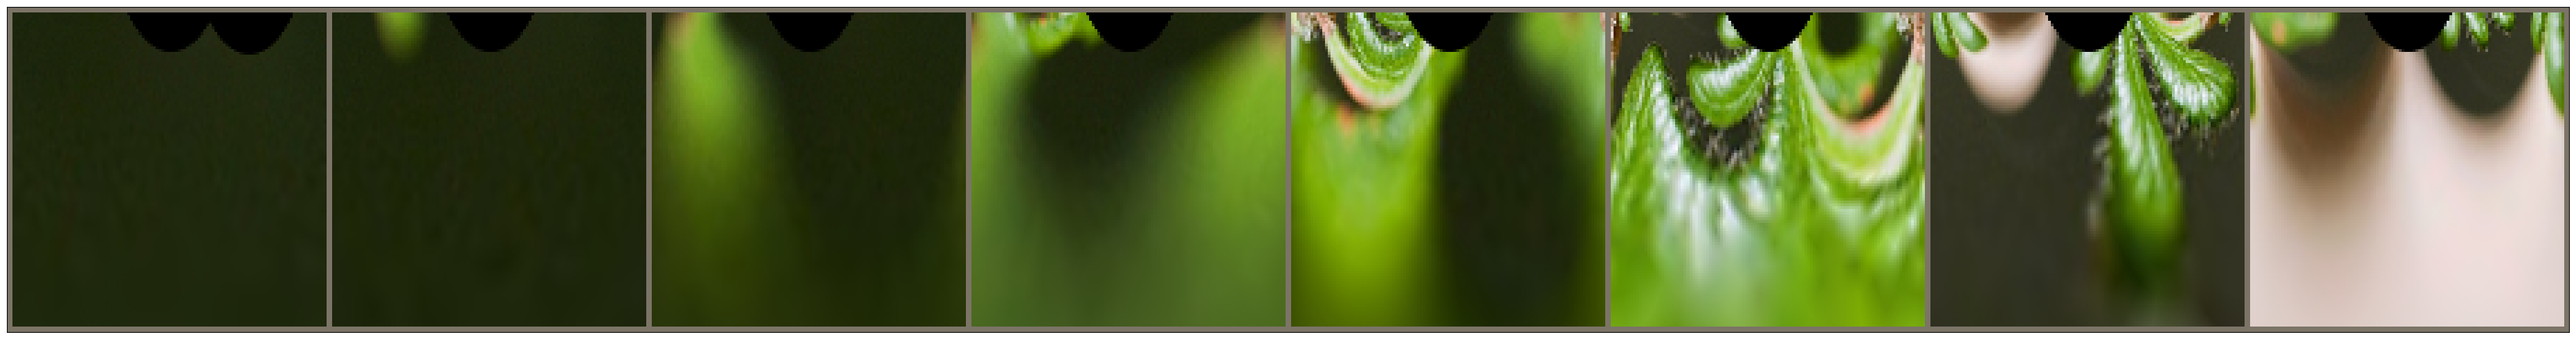

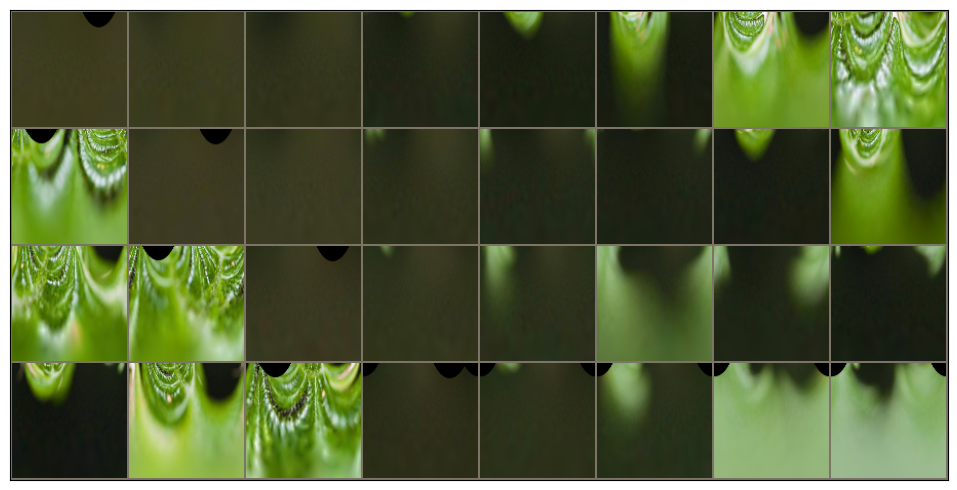

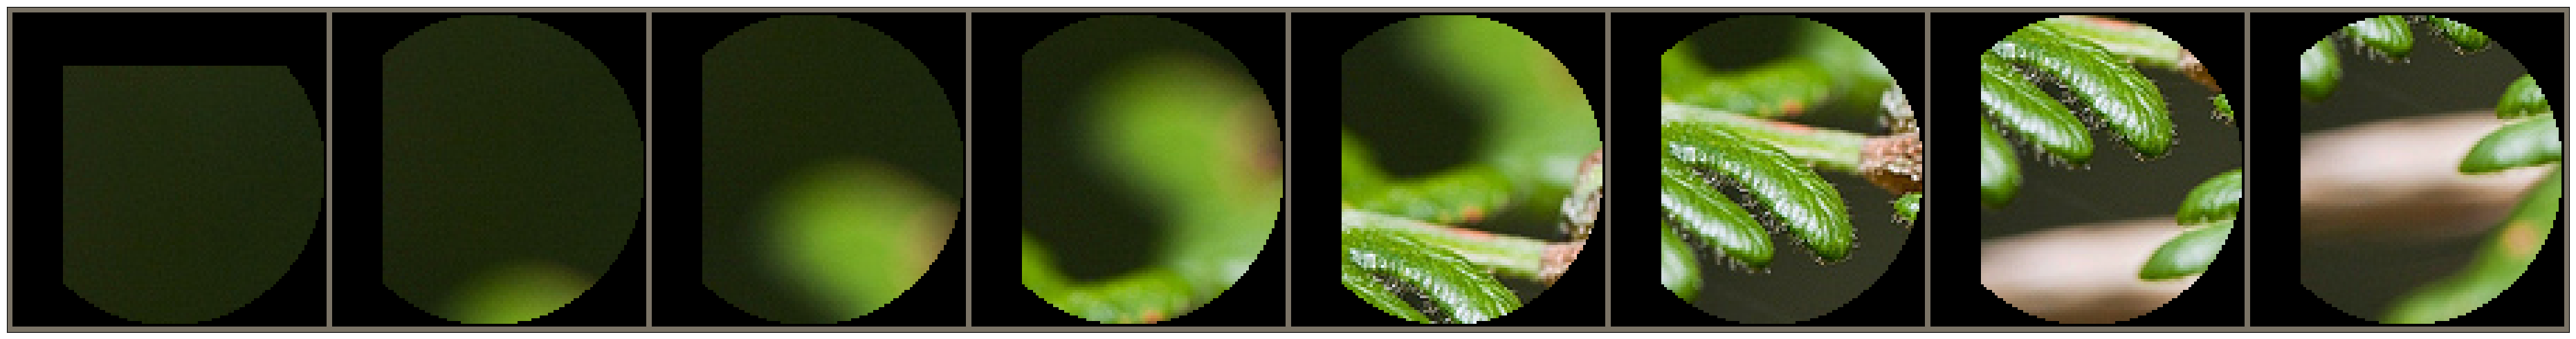

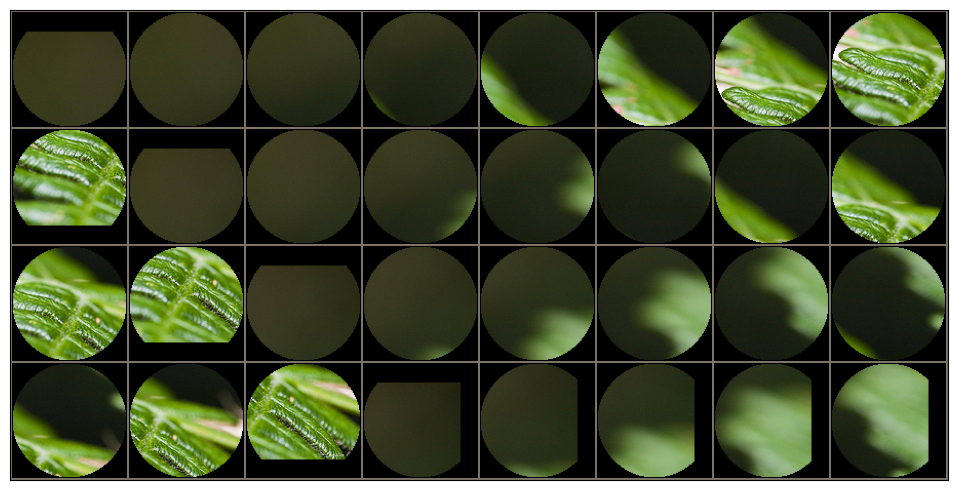

In [16]:
for do_polar in [True, False]:
    print(f'{do_polar=}')
    args.image_size = box_size
    args.do_polar = do_polar
    data_transform = get_transforms(args)
    cropped_images = torch.empty((N_fixations, 3, box_size, box_size))
    for i_fixation, (h, w) in enumerate(zip(pos_H.ravel(), pos_W.ravel())):
        h, w = int(h), int(w)
        # cropped_image = full_image[:, h-box_size//2:h+box_size//2, w-box_size//2:w+box_size//2]
        cropped_image = crop(full_image, h-box_size//2, w-box_size//2, box_size, box_size)
        cropped_images[i_fixation, ...] = data_transform(cropped_image)
    imshow(cropped_images[0:8, ...])
    imshow(cropped_images[72:104, ...])

In [17]:
h, w

(337, 461)

In [18]:
cropped_images[12:36, ...].mean(axis=(1,2,3))

tensor([-0.831, -0.425, -0.485, -0.461, -0.459, -0.585, -1.661, -1.609, -1.338, -0.582, -0.074, -0.167, -0.376, -0.197, -0.521, -1.628,
        -1.558, -1.406, -0.566, -0.023, -0.094, -0.271, -0.304, -0.781])

In [19]:
outputs = {}
with torch.no_grad():
    data_set_type = 'focus'
    model_name = 'resnet101'
    for do_polar in [True, False]:
        print(f'{do_polar=}')
        args.image_size = box_size
        args.do_polar = do_polar
        data_transform = get_transforms(args)
        cropped_images = torch.empty((N_fixations, 3, box_size, box_size))
        for i_fixation, (h, w) in enumerate(zip(pos_H.ravel(), pos_W.ravel())):
            h, w = int(h), int(w)
            cropped_image = crop(full_image, h-box_size//2, w-box_size//2, box_size, box_size)
            cropped_images[i_fixation, ...] = data_transform(cropped_image)

        model_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}.pt'

        print(f"Loading pre-trained resnet {model_filename}")
        model = charge_model(model_name=model_name, model_path=model_filename, 
                             do_circular=args.do_polar).to(device).eval()

        cropped_images = cropped_images.to(device)

        outputs[do_polar] = torch.nn.functional.softmax(model(cropped_images), dim=1)


do_polar=True
Loading pre-trained resnet cached_data/2024-05-14_focus_resnet101_do_polar=True.pt
loading .... cached_data/2024-05-14_focus_resnet101_do_polar=True.pt


FileNotFoundError: [Errno 2] No such file or directory: 'cached_data/2024-05-14_focus_resnet101_do_polar=True.pt'

In [ ]:
outputs[False].shape

In [ ]:
for do_polar in [True, False]:
    probas, preds = torch.max(outputs[do_polar], dim=1)
    # detect = (preds == labels.data).cpu().numpy()
    for proba, pred in zip(probas, preds):
        print(f'{proba.item():.3f},\t\t\t\t {labels[pred]}')

In [ ]:
outputs[True].shape

In [ ]:
# for pred in preds:
#     print(labels[pred])

In [ ]:
labels[i_labels_dico[true_label]]

In [ ]:
labels_dico[true_label], i_labels_dico[true_label]

In [ ]:
proba_label = outputs[True][:, i_labels_dico[true_label]].detach().cpu().numpy()
proba_label

In [ ]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.imshow(full_image_np)
# ax.set_xticks([])
for do_polar in [True, False]:
    proba_label = outputs[do_polar][:, i_labels_dico[true_label]].detach().cpu().numpy()
    ax.scatter(pos_W.ravel(), pos_H.ravel(), s=proba_label*1000, c='r' if do_polar else 'b')
# ax.scatter(500, 100, s=1000, c='r')
# ax.set_yticks([])  
fig.set_facecolor(color='white')

## as a function

In [ ]:
N_fixations, N_batch = 100, 32

In [ ]:
for idx in np.arange(0, N_fixations, N_batch):
    print(idx, np.min((idx+N_batch, N_fixations)))

### comparing mappings

In [ ]:
data_set_type = 'focus'
model_name = 'resnet101'


In [ ]:

outputs = {}
for do_polar in [True, False]:
    print(f'{do_polar=}')
    args.image_size = box_size
    args.do_polar = do_polar

    model_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}.pt'

    print(f"Loading pre-trained resnet {model_filename}")
    model = charge_model(model_name=model_name, model_path=model_filename, 
                         do_circular=args.do_polar).to(device).eval()
    
    pos_H, pos_W, outputs[do_polar] = compute_likelihood_map(args, model, full_image)


In [ ]:
outputs[True].shape, pos_H.shape

In [ ]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.imshow(full_image_np)
# ax.set_xticks([])
for do_polar in [True, False]:
    proba_label = outputs[do_polar][:, i_labels_dico[true_label]]
    ax.scatter(pos_W.ravel(), pos_H.ravel(), s=proba_label*1000, c='r' if do_polar else 'b')
# ax.scatter(500, 100, s=1000, c='r')
# ax.set_yticks([])  
fig.set_facecolor(color='white')

### comparing methods

In [ ]:
data_set_type = 'focus'
model_name = 'resnet101'
do_polar = True

outputs = {}
for method in ['full', 'valid']:
    print(f'{method=}')
    args.image_size = box_size
    args.do_polar = do_polar

    model_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}.pt'

    print(f"Loading pre-trained resnet {model_filename}")
    model = charge_model(model_name=model_name, model_path=model_filename, 
                         do_circular=args.do_polar).to(device).eval()
    
    N_fixations = np.prod(resolution)
    aspect_ratio = full_image.shape[1]/full_image.shape[2]
    resolution_ = (int(np.sqrt(N_fixations*aspect_ratio)),
                    int(np.sqrt(N_fixations/aspect_ratio)))

    pos_H, pos_W, outputs[method] = compute_likelihood_map(args, model, full_image, resolution=resolution_, method=method)
    print(pos_W.ravel().shape, pos_H.ravel().shape, outputs[method].shape)


In [ ]:
resolution_

In [ ]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.imshow(full_image_np)
# ax.set_xticks([])
for method in ['full', 'valid']:
    if method=='full':
        resolution_ = (int(np.sqrt(N_fixations*aspect_ratio)),int(np.sqrt(N_fixations/aspect_ratio)))
    else: 
        resolution_ = resolution

    pos_H, pos_W, box_size = get_positions(full_image, resolution_, size_ratio, method=method)
    proba_label = outputs[method][:, i_labels_dico[true_label]]
    print(pos_W.ravel().shape, pos_H.ravel().shape, proba_label.shape)
    ax.scatter(pos_W.ravel(), pos_H.ravel(), s=proba_label*1000, c='r' if method=='full' else 'b')
# ax.scatter(500, 100, s=1000, c='r')
# ax.set_yticks([])  
fig.set_facecolor(color='white')

In [ ]:
outputs